In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from wordcloud import WordCloud

sns.set(style="whitegrid")

In [2]:
df = pd.read_csv("SMSSpamCollection.txt", sep="\t", header=None, names=["label", "text"])
df.head()

,label,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [3]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-z ]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["clean"] = df["text"].apply(clean_text)
df.head()


df["lemma"] = df["clean"]
df.head()

,label,text,clean,lemma
0,ham,"Go until jurong point, crazy.. Available only ...",go until jurong point crazy available only in ...,go until jurong point crazy available only in ...
1,ham,Ok lar... Joking wif u oni...,ok lar joking wif u oni,ok lar joking wif u oni
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,free entry in a wkly comp to win fa cup final ...,free entry in a wkly comp to win fa cup final ...
3,ham,U dun say so early hor... U c already then say...,u dun say so early hor u c already then say,u dun say so early hor u c already then say
4,ham,"Nah I don't think he goes to usf, he lives aro...",nah i don t think he goes to usf he lives arou...,nah i don t think he goes to usf he lives arou...


In [4]:
custom_stopwords = {
    "the", "a", "an", "and", "or", "to", "of", "in", "on", "for", "is", "are",
    "be", "am", "was", "were", "this", "that", "it", "you", "i", "me", "my",
    "we", "our", "us", "your"
}

def remove_stopwords(text):
    return " ".join([w for w in text.split() if w not in custom_stopwords])

df["no_stop"] = df["lemma"].apply(remove_stopwords)
df.head()
df["lemma"] = df["clean"]
df.head()

,label,text,clean,lemma,no_stop
0,ham,"Go until jurong point, crazy.. Available only ...",go until jurong point crazy available only in ...,go until jurong point crazy available only in ...,go until jurong point crazy available only bug...
1,ham,Ok lar... Joking wif u oni...,ok lar joking wif u oni,ok lar joking wif u oni,ok lar joking wif u oni
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,free entry in a wkly comp to win fa cup final ...,free entry in a wkly comp to win fa cup final ...,free entry wkly comp win fa cup final tkts st ...
3,ham,U dun say so early hor... U c already then say...,u dun say so early hor u c already then say,u dun say so early hor u c already then say,u dun say so early hor u c already then say
4,ham,"Nah I don't think he goes to usf, he lives aro...",nah i don t think he goes to usf he lives arou...,nah i don t think he goes to usf he lives arou...,nah don t think he goes usf he lives around he...


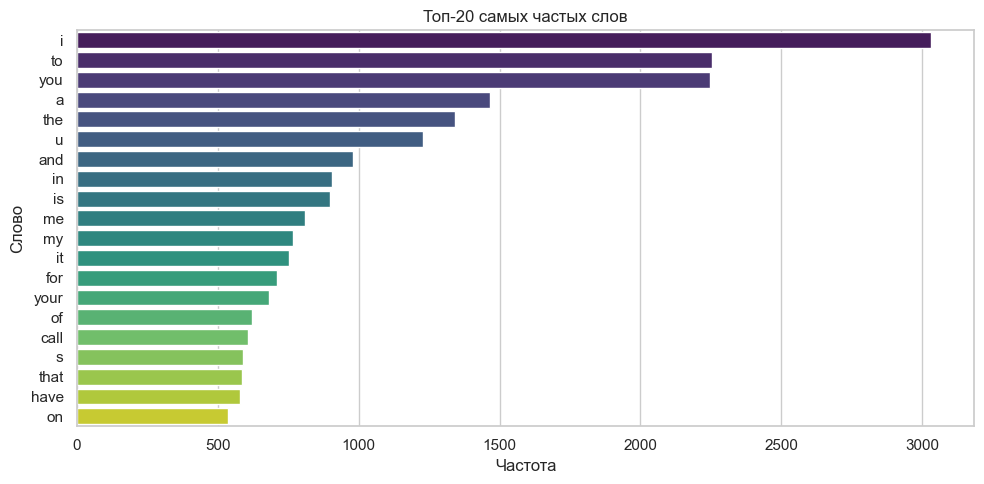

In [5]:
all_words = " ".join(df["lemma"]).split()
freq = pd.Series(all_words).value_counts().head(20)

plt.figure(figsize=(10, 5))
sns.barplot(x=freq.values, y=freq.index, palette="viridis", hue=freq.index, legend=False)
plt.title("Топ-20 самых частых слов")
plt.xlabel("Частота")
plt.ylabel("Слово")
plt.tight_layout()
plt.show()

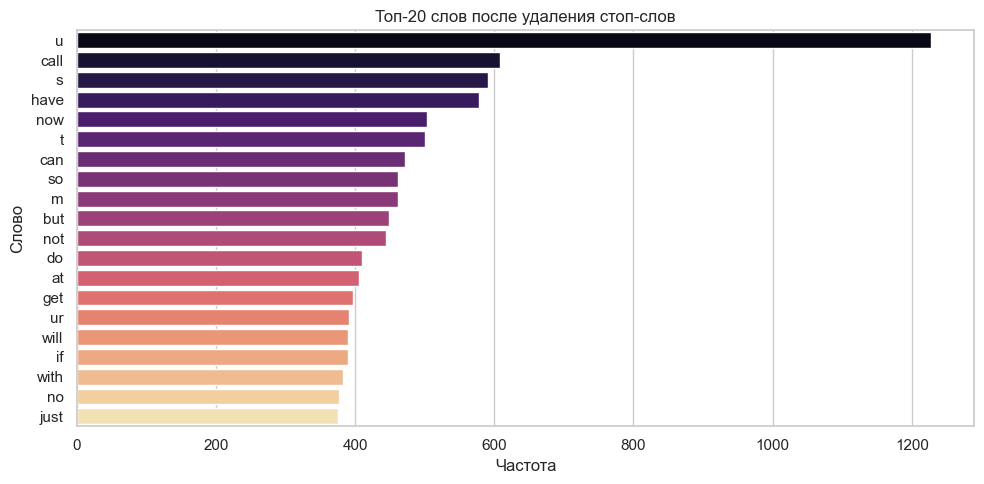

In [6]:
all_words2 = " ".join(df["no_stop"]).split()
freq2 = pd.Series(all_words2).value_counts().head(20)

plt.figure(figsize=(10, 5))
sns.barplot(x=freq2.values, y=freq2.index, palette="magma", hue=freq2.index, legend=False)
plt.title("Топ-20 слов после удаления стоп-слов")
plt.xlabel("Частота")
plt.ylabel("Слово")
plt.tight_layout()
plt.show()

In [7]:
vectorizer = TfidfVectorizer(max_features=1000)
tfidf = vectorizer.fit_transform(df["no_stop"])

def search(query, top_n=3):
    q_clean = clean_text(query)
    q_no_stop = remove_stopwords(q_clean)
    q_vec = vectorizer.transform([q_no_stop])
    sims = cosine_similarity(q_vec, tfidf)[0]
    idx = sims.argsort()[-top_n:][::-1]
    return df.loc[idx, ["label", "text"]], sims[idx]

results, scores = search("free prize claim now")
results

,label,text
576,spam,"You have won ?1,000 cash or a ?2,000 prize! To..."
495,ham,Are you free now?can i call now?
650,spam,"You have won ?1,000 cash or a ?2,000 prize! To..."


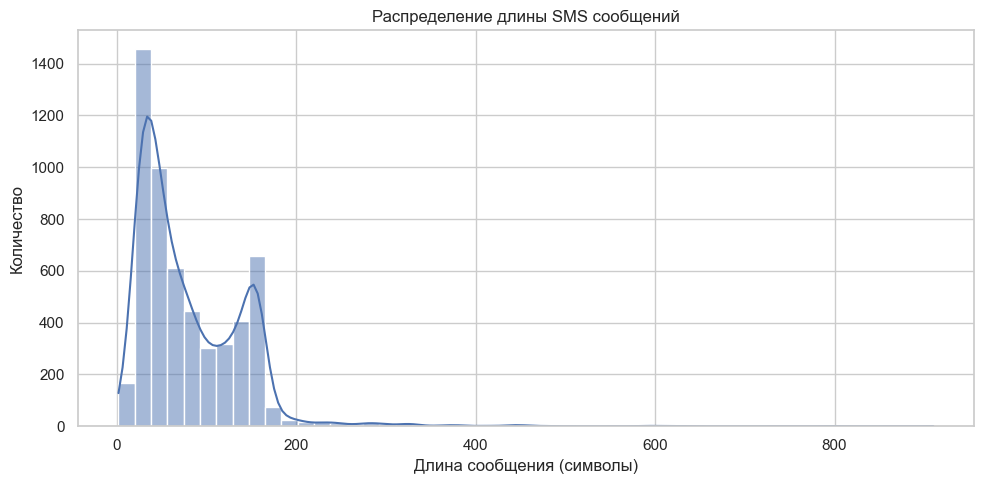

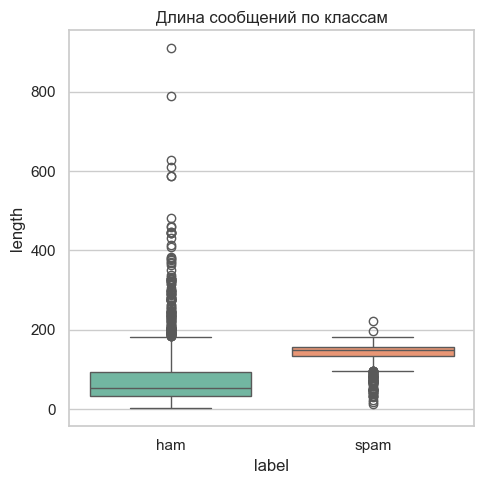

In [8]:
df["length"] = df["text"].apply(len)

plt.figure(figsize=(10, 5))
sns.histplot(df["length"], bins=50, kde=True)
plt.title("Распределение длины SMS сообщений")
plt.xlabel("Длина сообщения (символы)")
plt.ylabel("Количество")
plt.tight_layout()
plt.show()

plt.figure(figsize=(5, 5))
sns.boxplot(data=df, x="label", y="length", palette="Set2", hue="label", legend=False)
plt.title("Длина сообщений по классам")
plt.tight_layout()
plt.show()

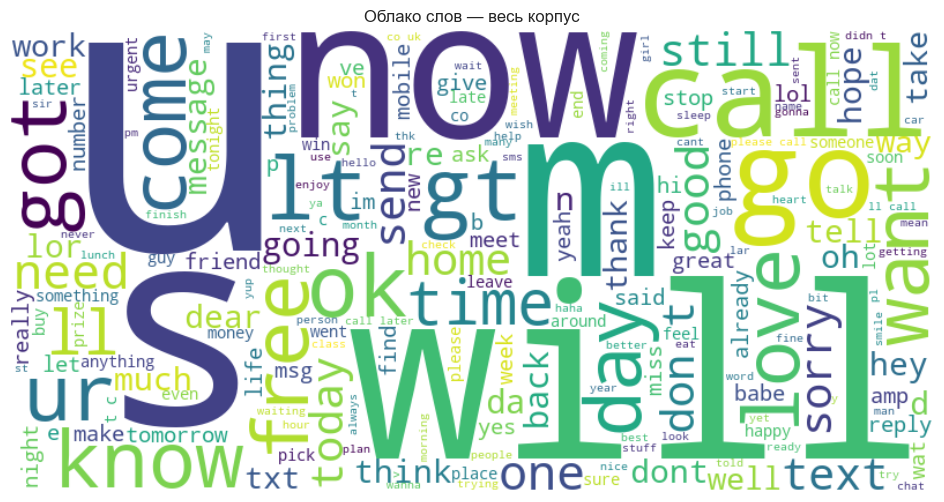

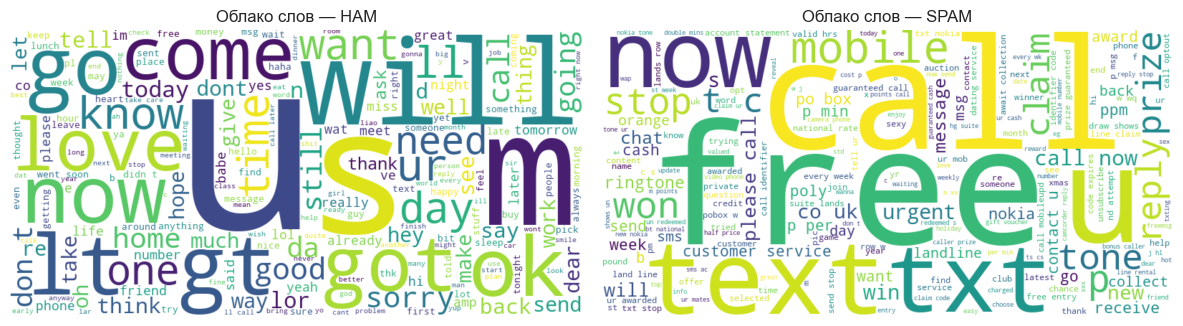

In [9]:
text_all = " ".join(df["lemma"])
wc = WordCloud(width=800, height=400, background_color="white").generate(text_all)

plt.figure(figsize=(12, 6))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("Облако слов — весь корпус")
plt.show()

text_ham = " ".join(df[df["label"]=="ham"]["lemma"])
text_spam = " ".join(df[df["label"]=="spam"]["lemma"])

wc_ham = WordCloud(width=800, height=400, background_color="white").generate(text_ham)
wc_spam = WordCloud(width=800, height=400, background_color="white").generate(text_spam)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(wc_ham, interpolation="bilinear")
plt.axis("off")
plt.title("Облако слов — HAM")

plt.subplot(1, 2, 2)
plt.imshow(wc_spam, interpolation="bilinear")
plt.axis("off")
plt.title("Облако слов — SPAM")

plt.tight_layout()
plt.show()

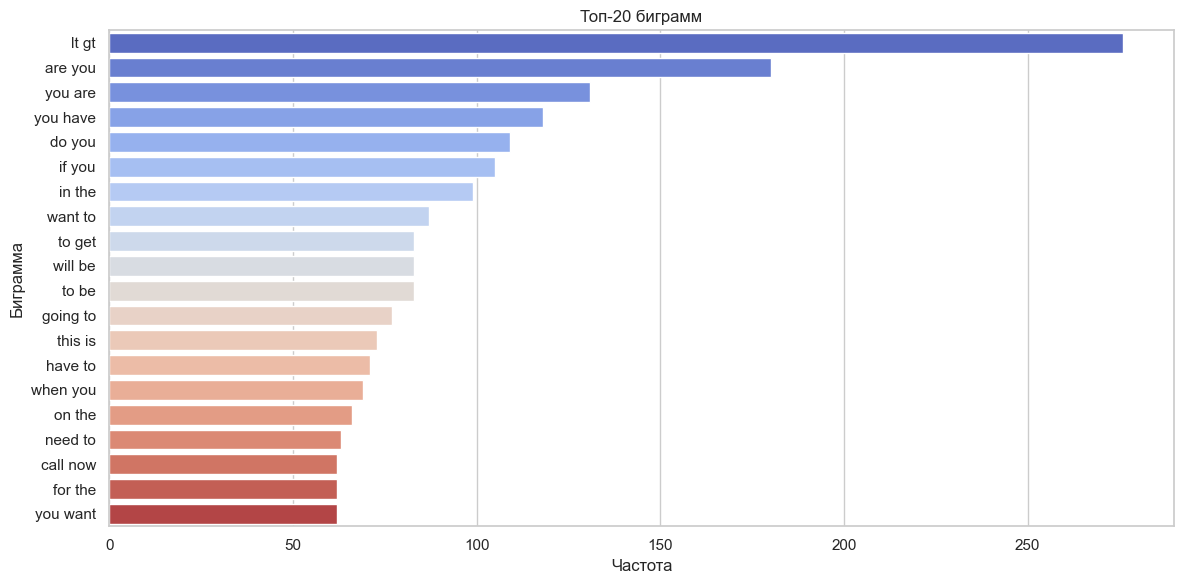

In [10]:
bigram_vectorizer = CountVectorizer(ngram_range=(2, 2), max_features=20)
X_bigrams = bigram_vectorizer.fit_transform(df["lemma"])

bigrams = pd.Series(
    np.sum(X_bigrams.toarray(), axis=0),
    index=bigram_vectorizer.get_feature_names_out()
).sort_values(ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x=bigrams.values, y=bigrams.index, palette="coolwarm", hue=bigrams.index, legend=False)
plt.title("Топ-20 биграмм")
plt.xlabel("Частота")
plt.ylabel("Биграмма")
plt.tight_layout()
plt.show()